<a href="https://colab.research.google.com/github/rosymrd/2025_Pengolahan-Citra_TI2A/blob/main/easyOCR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 98.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 422.8/422.8 kB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 969.6/969.6 kB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 292.9/292.9 kB 22.8 MB/s eta 0:00:00


Saving scaned_img_1.jpg to scaned_img_1 (2).jpg


Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete📌 Detected: B1OSKOPI (Confidence: 0.64)


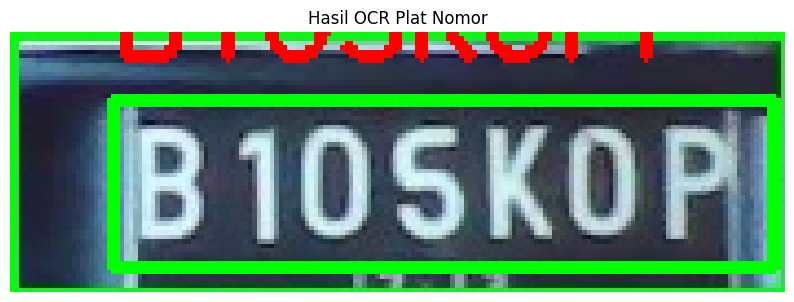

In [ ]:
# 1. Install EasyOCR
!pip install -q easyocr

# 2. Upload gambar secara manual
from google.colab import files
uploaded = files.upload()

# 3. Import library
import easyocr
import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# 4. Inisialisasi EasyOCR (gunakan bahasa Inggris)
reader = easyocr.Reader(['en'])

# 5. Ambil nama file yang baru diupload
filename = list(uploaded.keys())[0]

# 6. Baca gambar dan konversi ke RGB
img = cv2.imread(filename)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 7. Jalankan OCR
results = reader.readtext(img)

# 8. Gambar bounding box dan tampilkan hasil deteksi
for (bbox, text, prob) in results:
    (tl, tr, br, bl) = bbox
    tl = tuple(map(int, tl))
    br = tuple(map(int, br))
    cv2.rectangle(img_rgb, tl, br, (0, 255, 0), 2)
    cv2.putText(img_rgb, text, (tl[0], tl[1] - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)
    print(f"📌 Detected: {text.strip()} (Confidence: {prob:.2f})")

# 9. Tampilkan gambar hasil OCR
plt.figure(figsize=(10, 6))
plt.imshow(img_rgb)
plt.axis('off')
plt.title("Hasil OCR Plat Nomor")
plt.show()


Saving scaned_img_1.jpg to scaned_img_1 (4).jpg


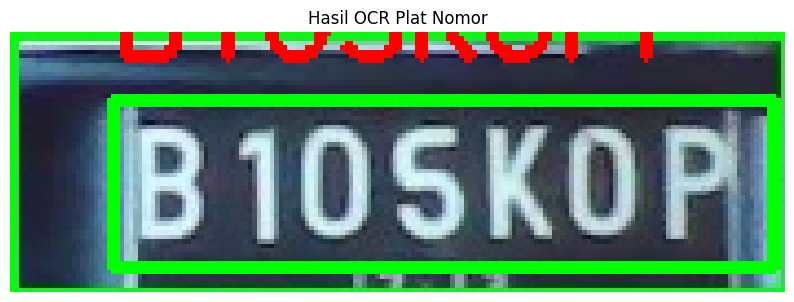

📌 Hasil Teks yang Terdeteksi:


**1.** `B1OSKOPI` (confidence: **0.64**)

In [ ]:
# 1. Install EasyOCR
!pip install -q easyocr

# 2. Upload gambar manual
from google.colab import files
uploaded = files.upload()

# 3. Import library
import easyocr
import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from IPython.display import display, Markdown

# 4. Inisialisasi EasyOCR
reader = easyocr.Reader(['en'])

# 5. Ambil nama file
filename = list(uploaded.keys())[0]

# 6. Baca gambar
img = cv2.imread(filename)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 7. Jalankan OCR
results = reader.readtext(img)

# 8. Gambar bounding box dan ambil hasil teks
detected_texts = []
for (bbox, text, prob) in results:
    (tl, tr, br, bl) = bbox
    tl = tuple(map(int, tl))
    br = tuple(map(int, br))
    cv2.rectangle(img_rgb, tl, br, (0, 255, 0), 2)
    cv2.putText(img_rgb, text, (tl[0], tl[1] - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)
    detected_texts.append((text.strip(), prob))

# 9. Tampilkan gambar hasil OCR
plt.figure(figsize=(10, 6))
plt.imshow(img_rgb)
plt.axis('off')
plt.title("Hasil OCR Plat Nomor")
plt.show()

# 10. Tampilkan teks hasil OCR
print("📌 Hasil Teks yang Terdeteksi:")
for i, (text, prob) in enumerate(detected_texts, start=1):
    display(Markdown(f"**{i}.** `{text}` (confidence: **{prob:.2f}**)"))

